# H1 — Does deeper liquidity shorten price gaps?

**Question.** Do gap episodes close faster when local depth is higher?
**Model.** $\ln T_i = \alpha + \beta \ln \bar D_i + \gamma_1 G_i + \gamma_2 S_i + \varepsilon_i$, where $T_i$ is the gap duration, $\bar D_i$ mean depth, $G_i$ mean gas and $S_i$ a gas-spike dummy; OLS with HC1 and day-clustered standard errors. Doubling depth changes the typical duration by $2^{\beta}-1$.

**Series.** $b_t = P_t - \frac{1}{50}\sum_{k=0}^{49}P_{t-k}$ (Binance close minus its 50-tick moving average) and $D_t$ a trailing mean of Binance volume over up to 1,000 ticks; both are proxies (see the README, *Data notes*).

In [1]:
import pandas as pd
from IPython.display import Image, display

from crosschain_arb import plots
from crosschain_arb.config import FIGURES_DIR

pd.options.display.float_format = "{:,.4f}".format


def show(path):
    display(Image(filename=str(path)))

In [2]:
from crosschain_arb.episodes import build_gap_episodes
from crosschain_arb.halflife import ar1_half_life
from crosschain_arb.io import load_panel
from crosschain_arb.models import fit_h1, logrank_by_depth_tercile
from crosschain_arb.panel import add_gas_spike

panel = add_gas_spike(load_panel())
hl = ar1_half_life(panel.set_index("time")["basis_t"], dt_seconds=1.0)
print(f"{len(panel):,} ticks | OU half-life {hl.half_life_s:.2f}s (phi = {hl.phi:.4f})")

ep_1s = build_gap_episodes(panel, min_seconds=1.0)
ep = build_gap_episodes(panel, min_seconds=5.0)
print(f"episodes: {len(ep_1s):,} (>=1s) -> {len(ep):,} (>=5s)")

1,017,975 ticks | OU half-life 9.97s (phi = 0.9328)


episodes: 20,074 (>=1s) -> 17,988 (>=5s)


## Estimate and variants

In [3]:
rows = {
    "main (>=5s)": fit_h1(ep),
    "all episodes (>=1s)": fit_h1(ep_1s),
    "winsorised depth 1/99 (>=1s)": fit_h1(ep_1s, winsorize_depth=True),
}
pd.DataFrame({k: v.to_dict() for k, v in rows.items()}).T[
    ["n", "beta_log_depth", "se_hc1", "se_cluster", "p_cluster", "adj_r2"]
]

,n,beta_log_depth,se_hc1,se_cluster,p_cluster,adj_r2
main (>=5s),17988,-0.2786,0.0276,0.0858,0.0012,0.0270
all episodes (>=1s),20074,-0.4488,0.0320,0.1409,0.0014,0.0310
winsorised depth 1/99 (>=1s),20074,-0.4622,0.0327,0.1469,0.0016,0.0311


A 1% increase in depth goes with about a 0.28% shorter gap (a doubling of depth: roughly −18%). The estimate holds across inference methods; day-clustering widens the standard error about three-fold but the effect stays significant. The fit is modest (adjusted R² ≈ 0.03), as expected for second-by-second durations. Notebook 06 runs 17 further variants.

## Survival by depth tercile

{'median_duration_low': 79.943, 'median_duration_high': 64.5435, 'p_logrank': 0.10416867523616653}


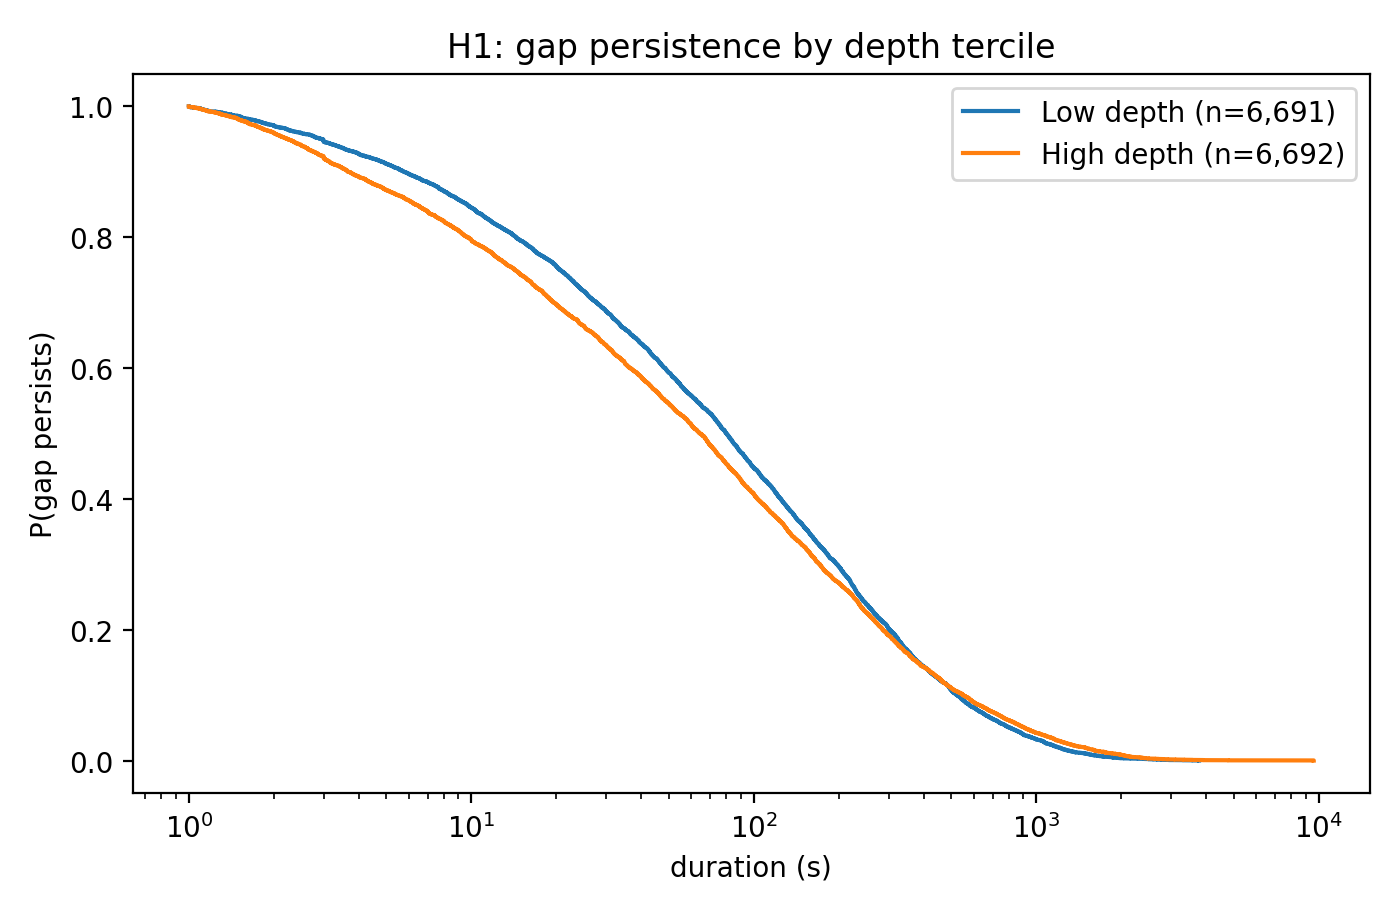

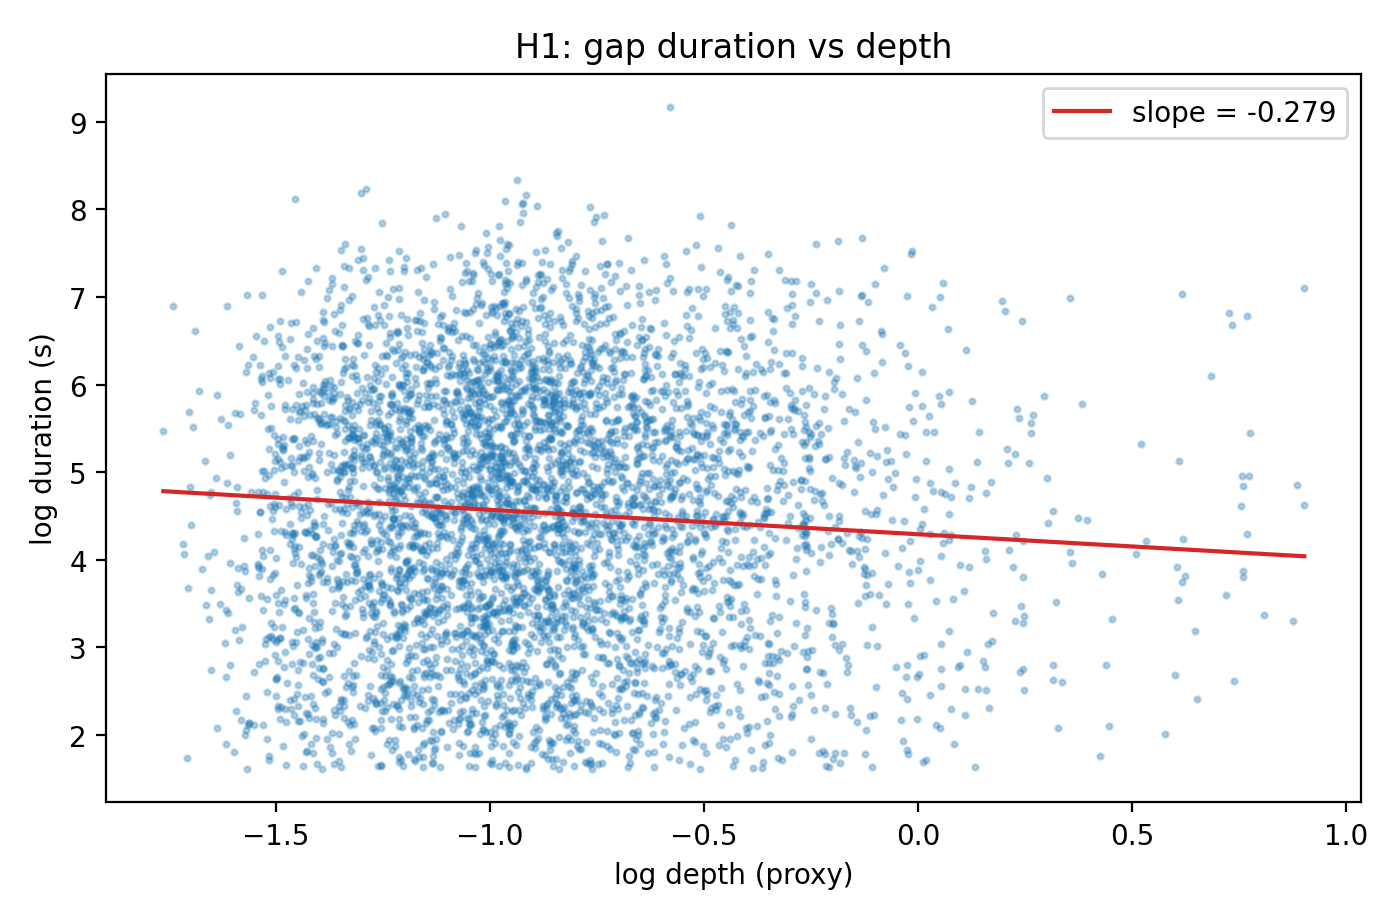

In [4]:
print(logrank_by_depth_tercile(ep_1s))
show(plots.plot_survival_by_depth(ep_1s, FIGURES_DIR / "h1_survival.png"))
show(plots.plot_h1_scatter(ep, FIGURES_DIR / "h1_scatter.png"))

Median durations are shorter in the high-depth tercile, in the direction of the regression, but the log-rank test between the lowest and highest terciles is not significant at 5% (p ≈ 0.10). The survival comparison therefore supports the regression only weakly.